In [1]:
import os
import rmgpy.chemkin
import rmgpy.tools.uncertainty

import numpy as np

import importlib
importlib.reload(rmgpy.tools.uncertainty)

import matplotlib.pyplot as plt
%matplotlib inline

# Show that the gas-phase sensitivities match whether using RMG or Cantera

In [2]:
chemkin = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/chem_annotated.inp'
spec_dict = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/species_dictionary.txt'
transport = '/home/moon/rmg/RMG-Py/examples/rmg/superminimal/chemkin/tran.dat'

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, transport_path=transport)

uncertainty = rmgpy.tools.uncertainty.Uncertainty(species_list=species_list, reaction_list=reaction_list)

def get_i_thing(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False
# C2H6 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='CC'), uncertainty.species_list)]
O2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[O][O]'), uncertainty.species_list)]
H2 = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[H][H]'), uncertainty.species_list)]
H2O = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='O'), uncertainty.species_list)]
Ar = uncertainty.species_list[get_i_thing(rmgpy.species.Species(smiles='[Ar]'), uncertainty.species_list)]


T = rmgpy.quantity.Quantity(1500, 'K')
P = rmgpy.quantity.Quantity(1.0, 'bar')
initial_mole_fractions = {
    # C2H6: 0.1,
    H2: 0.67,
    O2: 0.33,
    # Ar: 0.0,
}
termination_time = 0.1
sensitive_species = []
sensitive_species = [H2, H2O]
for sp in sensitive_species:
    display(sp)
 

## Run sensitivity using RMG

In [3]:
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    use_cantera=False
)

In [4]:
# load the simulation file
simulation_outfile = f'solver/simulation_1_{len(uncertainty.species_list)}.csv'
times_rmg, data_rmg = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_rmg = [d.label for d in data_rmg]

# simulation profile saves mols of core species
# https://github.com/ReactionMechanismGenerator/RMG-Py/blob/9cc2cfdedd6a7090d92782011d8f84c6292bce09/rmgpy/solver/base.pyx#L807


sens_1 = f'solver/sensitivity_1_SPC_{sensitive_species[0].index}.csv'
times1_rmg, data1_rmg = rmgpy.tools.plot.parse_csv_data(sens_1)
data_labels1_rmg = [d.label for d in data1_rmg]

sens_2 = f'solver/sensitivity_1_SPC_{sensitive_species[1].index}.csv'
times2_rmg, data2_rmg = rmgpy.tools.plot.parse_csv_data(sens_2)
data_labels2_rmg = [d.label for d in data2_rmg]

# then delete it just so there's no chance we're mixing it up with the Cantera version
os.remove(simulation_outfile)
os.remove(sens_1)
os.remove(sens_2)

# Run sensitivity using Cantera

In [5]:
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    use_cantera=True,
    cantera_file=chemkin.replace('.inp', '.yaml')
)

# load the simulation file
simulation_outfile = f'solver/simulation_1_{len(uncertainty.species_list)}.csv'
times_ct, data_ct = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_ct = [d.label for d in data_ct]

sens_1 = f'solver/sensitivity_1_SPC_{sensitive_species[0].index}.csv'
times1_ct, data1_ct = rmgpy.tools.plot.parse_csv_data(sens_1)
data_labels1_ct = [d.label for d in data1_ct]

sens_2 = f'solver/sensitivity_1_SPC_{sensitive_species[1].index}.csv'
times2_ct, data2_ct = rmgpy.tools.plot.parse_csv_data(sens_2)
data_labels2_ct = [d.label for d in data2_ct]

# then delete it just so there's no chance we're mixing it up with the Cantera version
os.remove(simulation_outfile)
os.remove(sens_1)
os.remove(sens_2)

# plot concentrations

Text(0, 0.5, 'Concentration mol/m^3')

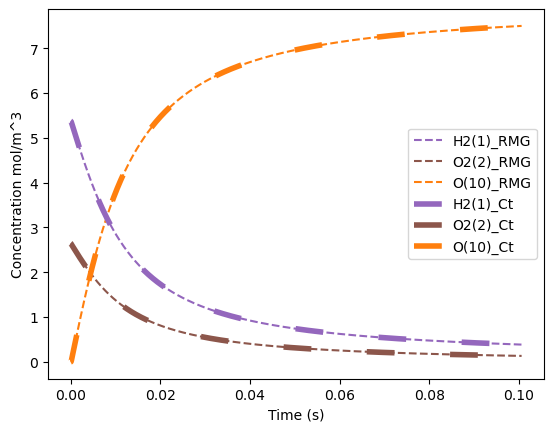

In [6]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
threshold_conc = 0.1
for i in range(len(species_list)):
    conc = np.divide(data_rmg[i + 1].data, data_rmg[0].data)
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_rmg.data, conc, label=data_labels_rmg[i+1] + '_RMG', linestyle='dashed', color=colors[i % len(colors)])


for i in range(len(species_list)):
    conc = np.divide(data_ct[i + 3].data, data_ct[0].data)
    if np.max(conc) < threshold_conc:
        continue
    plt.plot(times_ct.data, conc, label=data_labels_ct[i+3] + '_Ct', linestyle=(0, (5, 10)), color=colors[i % len(colors)], linewidth=4.0)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Concentration mol/m^3')

# Plot sensitivity

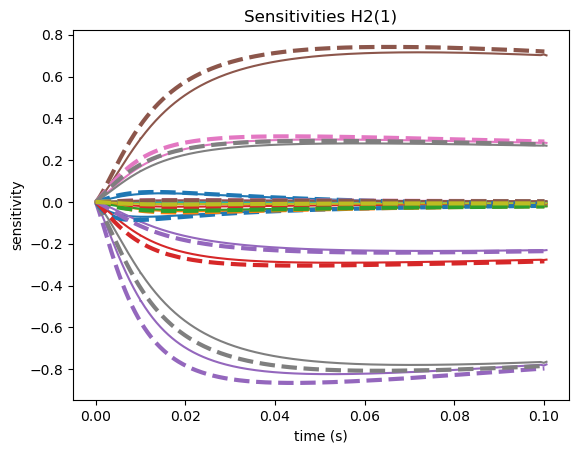

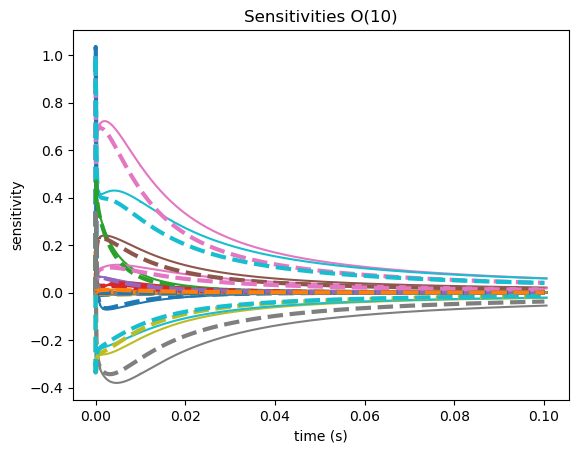

In [7]:
threshold_conc = 0.1
for i in range(len(data1_rmg)):
    plt.plot(times1_rmg.data, data1_rmg[i].data, label=data_labels1_rmg[i] + '_RMG', color=colors[i % len(colors)])

for i in range(len(data1_ct)):
    plt.plot(times1_ct.data, data1_ct[i].data, label=data_labels1_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.title(f'Sensitivities {sensitive_species[0]}')
plt.xlabel('time (s)')
plt.ylabel('sensitivity')
plt.show()


for i in range(len(data2_rmg)):
    plt.plot(times2_rmg.data, data2_rmg[i].data, label=data_labels2_rmg[i] + '_RMG', color=colors[i % len(colors)])

for i in range(len(data2_ct)):
    plt.plot(times2_ct.data, data2_ct[i].data, label=data_labels2_ct[i] + '_Ct', linestyle='dashed', color=colors[i % len(colors)], linewidth=3.0)

plt.title(f'Sensitivities {sensitive_species[1]}')
plt.xlabel('time (s)')
plt.ylabel('sensitivity')
plt.show()
